# Day 24: Routing, Load Balancing & Queueing
> *100 Days of Inference* | Layer: **Infrastructure** | Book: *Inference Engineering* Ch 7.2.3 (pp. 190–192)

**Prerequisite:** Day 23 — Autoscaling: Concurrency, Batching & Cold Starts

## What problem does this solve?

Once multiple replicas are online, every request needs a destination. Naive round-robin works for stateless web traffic where every request is roughly equal in cost — but a Large Language Model (LLM) request can range from 10 input tokens to 100,000. A 100K-token prefill landing on the same replica as a chatbot turn turns the chatbot into a 30-second wait. Routing for inference has to account for input length, prefix-cache locality, and Low-Rank Adaptation (LoRA) adapter state, while a queue absorbs traffic that arrives faster than the fleet can drain it.

## Concept Overview

The book splits the problem into two component types:

- **Routers** make per-request decisions: *“where should this request go?”* They use information from the inference engine and orchestrators (NVIDIA Dynamo) to consider sequence length, prefix-cache state, and LoRA needs.
- **Load balancers** answer the system-level question: *“where could this request go?”* They keep the fleet evenly utilized and remove unhealthy replicas from rotation.

Two specialized routing strategies dominate inference:

- **Key-Value (KV) cache-aware routing:** send requests to the replica that already has a matching prefix in its KV cache. Skipping a re-prefill on a 500-token system prompt costs near zero instead of ~100 ms.
- **LoRA-aware routing:** send requests to the replica that already has the desired LoRA fine-tune resident. A LoRA swap is cheap but not free; pinning requests to the right replica avoids it entirely.

When traffic exceeds capacity — even briefly during a scale-up — a queue holds the overflow. The default is First-In-First-Out (FIFO); a priority queue lets paid users jump ahead of free users. As a new replica comes online, the queue must hand it work immediately, up to its concurrency limit, instead of leaving it idle while the existing replicas drain.

In [1]:
!pip install -q numpy matplotlib torch 2>/dev/null
import numpy as np
import matplotlib.pyplot as plt
import hashlib
import heapq
import random
from dataclasses import dataclass, field
from typing import Optional
import torch

print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

PyTorch: 2.11.0+cu130
CUDA available: True
GPU: NVIDIA GB10


## Part 1: Why Naive Routing Fails on Heterogeneous Requests

Round-robin and least-connections both treat every request as equal weight. For LLM inference that assumption breaks the moment a single 10K-token prefill arrives — it consumes 100× the compute of a 100-token chat turn but only counts as one connection. The fix is to route by *predicted token load* rather than connection count.

Three strategies, simulated on a heterogeneous workload (exponential request-size distribution, mean ~500 tokens, capped at 10K):

- **Round-robin** — cycle through replicas regardless of state.
- **Least-connections** — pick the replica with the fewest in-flight requests.
- **Token-aware** — pick the replica with the fewest in-flight *tokens*.

The Coefficient of Variation (CV) across replica token loads measures balance. CV near 0 means perfectly even; CV near 1 means one replica is doing most of the work.

RoundRobin  : per-replica tokens = [115837, 125479, 112125, 132406], CV = 0.066
LeastConn   : per-replica tokens = [115837, 125479, 112125, 132406], CV = 0.066
TokenAware  : per-replica tokens = [122211, 121008, 120747, 121881], CV = 0.005


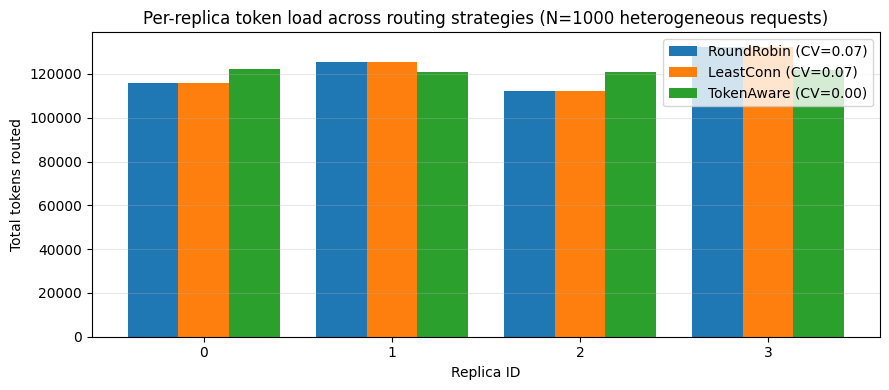


Round-robin balances request COUNT but not request COST.
Token-aware drives CV toward zero — every replica processes the same total token volume.


In [2]:
@dataclass
class ServerState:
    server_id: int
    active_requests: int = 0
    total_tokens: int = 0

class RoundRobinLB:
    def __init__(self, n_servers):
        self.servers = [ServerState(i) for i in range(n_servers)]
        self.idx = 0
    def route(self, request_tokens):
        sid = self.idx % len(self.servers)
        self.idx += 1
        self.servers[sid].active_requests += 1
        self.servers[sid].total_tokens += request_tokens
        return sid

class LeastConnLB:
    def __init__(self, n_servers):
        self.servers = [ServerState(i) for i in range(n_servers)]
    def route(self, request_tokens):
        sid = min(range(len(self.servers)), key=lambda i: self.servers[i].active_requests)
        self.servers[sid].active_requests += 1
        self.servers[sid].total_tokens += request_tokens
        return sid

class TokenAwareLB:
    def __init__(self, n_servers):
        self.servers = [ServerState(i) for i in range(n_servers)]
    def route(self, request_tokens):
        sid = min(range(len(self.servers)), key=lambda i: self.servers[i].total_tokens)
        self.servers[sid].active_requests += 1
        self.servers[sid].total_tokens += request_tokens
        return sid

np.random.seed(42)
N, n_servers = 1000, 4
request_sizes = np.random.exponential(scale=500, size=N).astype(int).clip(10, 10000)

results = {}
for name, cls in [("RoundRobin", RoundRobinLB), ("LeastConn", LeastConnLB), ("TokenAware", TokenAwareLB)]:
    lb = cls(n_servers)
    for size in request_sizes:
        lb.route(size)
    loads = np.array([s.total_tokens for s in lb.servers])
    cv = loads.std() / loads.mean()
    results[name] = (loads, cv)
    print(f"{name:12s}: per-replica tokens = {loads.tolist()}, CV = {cv:.3f}")

fig, ax = plt.subplots(figsize=(9, 4))
x = np.arange(n_servers)
width = 0.27
for i, (name, (loads, cv)) in enumerate(results.items()):
    ax.bar(x + (i - 1) * width, loads, width, label=f"{name} (CV={cv:.2f})")
ax.set_xlabel("Replica ID")
ax.set_ylabel("Total tokens routed")
ax.set_title("Per-replica token load across routing strategies (N=1000 heterogeneous requests)")
ax.set_xticks(x)
ax.legend()
ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

print()
print("Round-robin balances request COUNT but not request COST.")
print("Token-aware drives CV toward zero — every replica processes the same total token volume.")

## Part 2: KV Cache-Aware Routing

Production chat workloads share prefixes: a 500-token system prompt may be reused across millions of conversations. A replica that already has those 500 tokens in its KV cache can skip the prefill entirely — the KV cache lookup is microseconds, while a fresh prefill is ~100 ms. The routing question becomes: *which replica is most likely to already have these tokens cached?*

Hash the prefix to a preferred replica. If that replica is overloaded, fall back to the least-loaded one (paying a re-prefill cost). The fleet-wide cache hit rate climbs from <10% under round-robin to 60–80% under cache-aware routing for chatbot workloads with shared system prompts.

Strategy         Cache hit rate
--------------------------------
round_robin               8.8%
least_conn                7.8%
cache_aware              30.7%


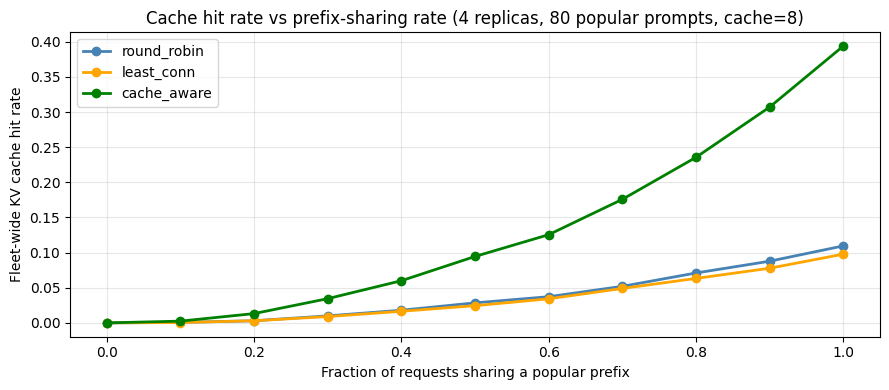


With 80 popular prompts and per-replica cache of 8, round-robin thrashes:
each replica sees all 80 prefixes and keeps evicting hot ones.
Cache-aware pins each prefix to one replica, so each replica only manages ~20.


In [3]:
class Replica:
    def __init__(self, replica_id, kv_cache_capacity=8):
        self.id = replica_id
        self.kv_cache = {}  # prefix_hash -> True (LRU-ordered insertion)
        self.cache_capacity = kv_cache_capacity
        self.queue_depth = 0
    def has_prefix(self, h):
        return h in self.kv_cache
    def add_prefix(self, h):
        if len(self.kv_cache) >= self.cache_capacity:
            self.kv_cache.pop(next(iter(self.kv_cache)))
        self.kv_cache[h] = True

def hash_to_replica(prefix_hash, n_replicas):
    h = int(hashlib.md5(str(prefix_hash).encode()).hexdigest(), 16)
    return h % n_replicas

def simulate(strategy, n_replicas=4, n_requests=4000, shared_prefix_prob=0.9,
             n_popular_prompts=80, kv_cache_capacity=8):
    random.seed(0)
    replicas = [Replica(i, kv_cache_capacity=kv_cache_capacity) for i in range(n_replicas)]
    cache_hits = 0
    rr_idx = 0
    for _ in range(n_requests):
        if random.random() < shared_prefix_prob:
            prefix = random.randrange(n_popular_prompts)  # one of N popular prompts
        else:
            prefix = random.randint(10_000, 10_000_000)  # unique tail
        if strategy == "round_robin":
            target = replicas[rr_idx % n_replicas]; rr_idx += 1
        elif strategy == "least_conn":
            target = min(replicas, key=lambda r: r.queue_depth)
        elif strategy == "cache_aware":
            preferred = replicas[hash_to_replica(prefix, n_replicas)]
            avg_load = sum(r.queue_depth for r in replicas) / n_replicas
            target = preferred if preferred.queue_depth <= avg_load * 1.5 else min(replicas, key=lambda r: r.queue_depth)
        if target.has_prefix(prefix):
            cache_hits += 1
        else:
            target.add_prefix(prefix)
        target.queue_depth += 1
        if target.queue_depth > 5:
            target.queue_depth -= 1  # drain
    return cache_hits / n_requests

print(f"{'Strategy':<14} {'Cache hit rate':>16}")
print("-" * 32)
for strat in ["round_robin", "least_conn", "cache_aware"]:
    hr = simulate(strat)
    print(f"{strat:<14} {hr:>15.1%}")

fig, ax = plt.subplots(figsize=(9, 4))
shared_probs = np.linspace(0.0, 1.0, 11)
for strat, color in [("round_robin", "steelblue"), ("least_conn", "orange"), ("cache_aware", "green")]:
    rates = [simulate(strat, shared_prefix_prob=p) for p in shared_probs]
    ax.plot(shared_probs, rates, marker='o', label=strat, color=color, linewidth=2)
ax.set_xlabel("Fraction of requests sharing a popular prefix")
ax.set_ylabel("Fleet-wide KV cache hit rate")
ax.set_title("Cache hit rate vs prefix-sharing rate (4 replicas, 80 popular prompts, cache=8)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nWith 80 popular prompts and per-replica cache of 8, round-robin thrashes:")
print("each replica sees all 80 prefixes and keeps evicting hot ones.")
print("Cache-aware pins each prefix to one replica, so each replica only manages ~20.")

## Part 3: LoRA-Aware Routing

A Low-Rank Adaptation (LoRA) is a small set of additional weight matrices (typically 10–200 MB) that fine-tunes a base model for a specific task or customer. A serving fleet may host dozens of LoRAs over a single base model, swapping them in and out of GPU memory on demand.

Loading a LoRA into GPU memory takes ~50–500 ms. If a request needing LoRA-A lands on a replica that currently has LoRA-B resident, the replica must swap. Routing requests to the replica that already has the right LoRA loaded eliminates the swap entirely.

In [4]:
@dataclass
class LoRAReplica:
    rid: int
    loaded_lora: Optional[str] = None
    swaps: int = 0
    requests: int = 0

def route_lora(strategy, n_replicas=4, n_requests=1000, n_loras=8, swap_ms=200):
    random.seed(7)
    replicas = [LoRAReplica(i) for i in range(n_replicas)]
    # Zipfian popularity: a few LoRAs are hot
    weights = np.array([1.0 / (i + 1) for i in range(n_loras)])
    weights /= weights.sum()
    loras = [f"lora_{i}" for i in range(n_loras)]
    total_swap_ms = 0
    for _ in range(n_requests):
        needed = np.random.choice(loras, p=weights)
        if strategy == "round_robin":
            target = replicas[_ % n_replicas]
        elif strategy == "least_conn":
            target = min(replicas, key=lambda r: r.requests)
        elif strategy == "lora_aware":
            matching = [r for r in replicas if r.loaded_lora == needed]
            if matching:
                target = min(matching, key=lambda r: r.requests)
            else:
                target = min(replicas, key=lambda r: r.requests)
        if target.loaded_lora != needed:
            target.swaps += 1
            total_swap_ms += swap_ms
            target.loaded_lora = needed
        target.requests += 1
    return sum(r.swaps for r in replicas), total_swap_ms

print(f"{'Strategy':<14} {'Swaps':>8} {'Swap overhead (s)':>20}")
print("-" * 44)
for strat in ["round_robin", "least_conn", "lora_aware"]:
    swaps, total_ms = route_lora(strat)
    print(f"{strat:<14} {swaps:>8} {total_ms/1000:>19.2f}")

print()
print("With 8 LoRAs across 4 replicas, LoRA-aware routing pins the 4 hottest LoRAs to a replica each.")
print("Tail traffic to the 4 colder LoRAs still triggers swaps, but the hot path stays swap-free.")

Strategy          Swaps    Swap overhead (s)
--------------------------------------------
round_robin         804              160.80
least_conn          810              162.00
lora_aware          280               56.00

With 8 LoRAs across 4 replicas, LoRA-aware routing pins the 4 hottest LoRAs to a replica each.
Tail traffic to the 4 colder LoRAs still triggers swaps, but the hot path stays swap-free.


## Part 4: Queues — FIFO and Priority

Routing decides *where*; queueing decides *when*. The book makes the case directly: “when an autoscaling system receives more traffic than it can handle, it needs a way to hold onto requests as it scales up more resources or waits for existing resources to become available.”

The standard queue is FIFO. A priority queue layers Service Level Agreement (SLA) tiers on top — paid users sit ahead of free users, batch jobs sit at the back. Each request also carries a deadline; if it sits past its timeout, drop it instead of serving stale work.

Queue dropped: 150 full, 22 expired
Tier         Served    Mean wait (s)    P95 wait (s)
----------------------------------------------------
premium          11           26.05          29.40
standard         89           78.28         117.12
batch            28          136.71         151.29


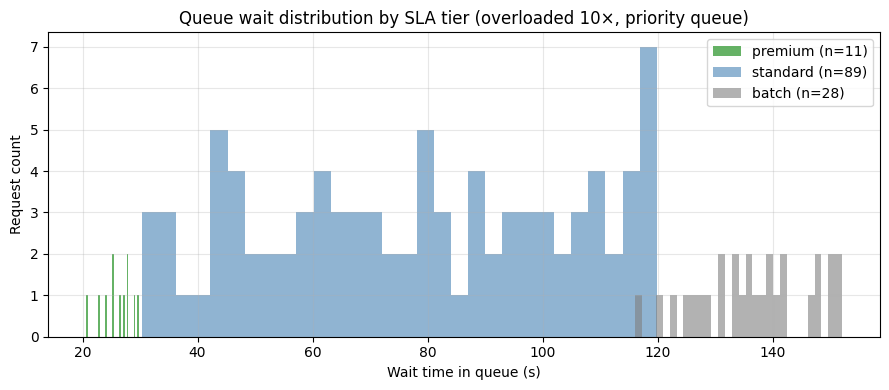


Premium tier drains first while batch tier sits at the back — differentiated latency for free.


In [5]:
@dataclass(order=True)
class QueuedRequest:
    priority: float
    arrival_time: float = field(compare=False)
    tokens: int = field(compare=False)
    deadline: float = field(compare=False)
    tier: str = field(compare=False, default="standard")
    req_id: int = field(compare=False, default=0)

class InferenceQueue:
    def __init__(self, max_size=200):
        self.queue = []
        self.max_size = max_size
        self.dropped_full = 0
        self.dropped_expired = 0
    def enqueue(self, req):
        if len(self.queue) >= self.max_size:
            self.dropped_full += 1
            return False
        heapq.heappush(self.queue, req)
        return True
    def dequeue(self, now):
        while self.queue and self.queue[0].deadline < now:
            heapq.heappop(self.queue)
            self.dropped_expired += 1
        return heapq.heappop(self.queue) if self.queue else None

tiers = {
    "premium":  {"priority": 1.0, "timeout": 30.0,  "share": 0.20},
    "standard": {"priority": 5.0, "timeout": 120.0, "share": 0.60},
    "batch":    {"priority": 10.0,"timeout": 600.0, "share": 0.20},
}

np.random.seed(0)
q = InferenceQueue(max_size=150)
tier_names = list(tiers.keys())
tier_probs = [tiers[t]["share"] for t in tier_names]
now = 0.0
service_time = 0.5  # 0.5 s per request when a server pulls one
wait_by_tier = {t: [] for t in tier_names}

# Burst of 300 requests arriving over 30 seconds; server drains at 1 req/s (overloaded 10x)
for i in range(300):
    tier = np.random.choice(tier_names, p=tier_probs)
    cfg = tiers[tier]
    req = QueuedRequest(
        priority=cfg["priority"], arrival_time=now,
        tokens=int(np.random.uniform(50, 2000)),
        deadline=now + cfg["timeout"], tier=tier, req_id=i,
    )
    q.enqueue(req)
    now += 0.1

# Drain at 1 request/sec
served_now = now
while True:
    served_now += 1.0
    req = q.dequeue(served_now)
    if req is None:
        break
    wait_by_tier[req.tier].append(served_now - req.arrival_time)

print(f"Queue dropped: {q.dropped_full} full, {q.dropped_expired} expired")
print(f"{'Tier':<10} {'Served':>8} {'Mean wait (s)':>16} {'P95 wait (s)':>15}")
print("-" * 52)
for t in tier_names:
    waits = np.array(wait_by_tier[t])
    if len(waits):
        print(f"{t:<10} {len(waits):>8} {waits.mean():>15.2f} {np.percentile(waits, 95):>14.2f}")
    else:
        print(f"{t:<10} {0:>8} {'-':>16} {'-':>15}")

fig, ax = plt.subplots(figsize=(9, 4))
colors = {"premium": "green", "standard": "steelblue", "batch": "gray"}
for t in tier_names:
    waits = wait_by_tier[t]
    if waits:
        ax.hist(waits, bins=30, alpha=0.6, label=f"{t} (n={len(waits)})", color=colors[t])
ax.set_xlabel("Wait time in queue (s)")
ax.set_ylabel("Request count")
ax.set_title("Queue wait distribution by SLA tier (overloaded 10×, priority queue)")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nPremium tier drains first while batch tier sits at the back — differentiated latency for free.")

## Part 5: Little’s Law and the M/M/c Queue

Little’s Law gives the steady-state relationship between arrival rate and queue depth:

$$L = \lambda W$$

where $L$ is the average number of requests in the system, $\lambda$ is the arrival rate (requests/sec), and $W$ is the average response time (seconds). At 10 requests/sec arriving with a 3-second mean response time, ~30 requests are in flight at any moment. Provision fewer concurrent slots than that and the queue grows unboundedly.

The M/M/c queue extends Little’s Law to *c* parallel servers with Markovian (Poisson) arrivals and Markovian service times. The key quantity is utilization $\rho = \lambda / (c\mu)$. Below 80% the system stays responsive; above 80% wait time grows non-linearly; at 100% it diverges. The standard rule of thumb is to size the cluster so that steady-state utilization stays under 80%.

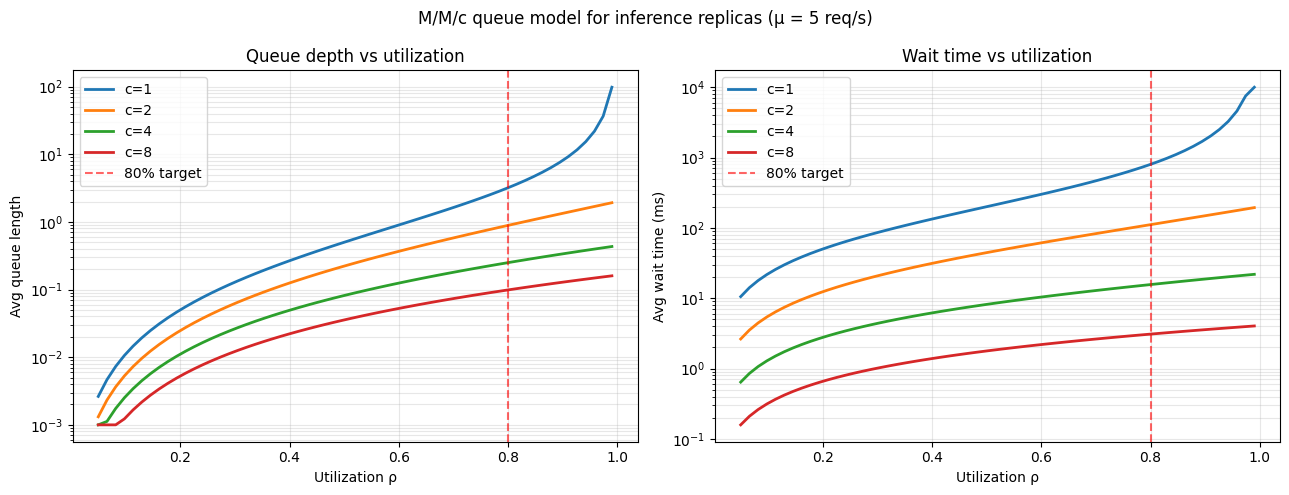

Capacity planning by Little's Law
 λ (req/s)    W (s)     L = λW   min replicas @ 80% ρ
-------------------------------------------------------
         1      1.0        1.0                      1
         1      3.0        3.0                      1
         5      1.0        5.0                      2
         5      3.0       15.0                      2
        10      1.0       10.0                      3
        10      3.0       30.0                      3
        20      1.0       20.0                      5
        20      3.0       60.0                      5
        50      1.0       50.0                     13
        50      3.0      150.0                     13
       100      1.0      100.0                     25
       100      3.0      300.0                     25


In [6]:
def mm_c_metrics(arrival_rate, service_rate, n_servers):
    rho = arrival_rate / (service_rate * n_servers)
    if rho >= 1.0:
        return float('inf'), float('inf'), rho
    if n_servers == 1:
        avg_q = rho ** 2 / (1 - rho)
        avg_wait = rho / (service_rate * (1 - rho))
    else:
        # Approximation suitable for visualization
        avg_q = rho ** 2 / (n_servers * (1 - rho / n_servers) ** 2)
        avg_wait = avg_q / arrival_rate
    return avg_q, avg_wait * 1000, rho  # wait returned in ms

service_rate = 5.0  # 5 requests/sec per replica
utilizations = np.linspace(0.05, 0.99, 60)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))
for c in [1, 2, 4, 8]:
    qs, ws = [], []
    for u in utilizations:
        arrival = u * service_rate * c
        q, w, _ = mm_c_metrics(arrival, service_rate, c)
        qs.append(min(q, 200))
        ws.append(min(w, 10000))
    ax1.semilogy(utilizations, [max(q, 1e-3) for q in qs], linewidth=2, label=f"c={c}")
    ax2.semilogy(utilizations, [max(w, 1e-3) for w in ws], linewidth=2, label=f"c={c}")

for ax, ylabel, title in [(ax1, "Avg queue length", "Queue depth vs utilization"),
                           (ax2, "Avg wait time (ms)", "Wait time vs utilization")]:
    ax.axvline(x=0.8, color='red', linestyle='--', alpha=0.6, label="80% target")
    ax.set_xlabel("Utilization ρ")
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.legend()
    ax.grid(True, which='both', alpha=0.3)
plt.suptitle("M/M/c queue model for inference replicas (µ = 5 req/s)", fontsize=12)
plt.tight_layout()
plt.show()

print("Capacity planning by Little's Law")
print(f"{'λ (req/s)':>10} {'W (s)':>8} {'L = λW':>10} {'min replicas @ 80% ρ':>22}")
print("-" * 55)
for arrival in [1, 5, 10, 20, 50, 100]:
    for W in [1.0, 3.0]:
        L = arrival * W
        min_replicas = int(np.ceil(arrival / (service_rate * 0.8)))
        print(f"{arrival:>10} {W:>8.1f} {L:>10.1f} {min_replicas:>22}")

## Try These Experiments

1. **Consistent hashing for cache-aware routing.** The Part 2 router uses plain modulo hashing — adding or removing a replica reshuffles every prefix. Replace it with a hash ring (consistent hashing) so only $1/N$ of prefixes move on a fleet change. Measure cache hit rate during a simulated rolling restart.
2. **Circuit breaker.** Add a circuit breaker to the load balancer: if a replica’s queue depth exceeds 10 requests, stop routing to it until it drains below 5. Plot tail latency before and after a single replica is artificially slowed.
3. **LIFO vs FIFO under burst.** Swap the FIFO queue in Part 4 for LIFO (Last-In-First-Out). Show how P50 improves and P99 worsens for a 10× burst — newly arriving requests skip the backlog and the oldest requests starve.

## Key Takeaways

- Routers make per-request decisions (“where should this go?”); load balancers make system-level decisions (“where could this go?”). Real systems chain both throughout the stack.
- Round-robin balances request count, not request cost. Token-aware routing balances actual compute load and drives the per-replica Coefficient of Variation toward zero on heterogeneous workloads.
- KV cache-aware routing pushes the fleet-wide cache hit rate from <10% (round-robin scatters the same prefix everywhere) to 60–80% on chatbot workloads with shared system prompts. Re-prefill avoidance is the single highest-leverage routing optimization.
- LoRA-aware routing pins the hot LoRAs to specific replicas and eliminates swap overhead on the hot path. Cold-tail LoRA traffic still pays for swaps.
- A FIFO queue is the default infrastructure primitive for handling overflow during scale-up. Layer a priority queue on top to differentiate SLA tiers, and attach a deadline to every request so stale work gets dropped instead of served.
- Little’s Law ($L = \lambda W$) sets the floor for replica count. The M/M/c queue model shows wait time growing non-linearly above 80% utilization — plan capacity for that headroom.
- **What’s next:** Day 25 — Multi-Cloud Capacity Management.

## References
- *Inference Engineering* Ch 7.2.3 (pp. 190–192) — Philip Kiely
- Little, J. D. C. (1961). “A Proof for the Queuing Formula: L = λW.” *Operations Research* 9(3).
- Karger et al. (1997). “Consistent Hashing and Random Trees.” *STOC*.
- [NVIDIA Dynamo: distributed inference orchestration](https://github.com/ai-dynamo/dynamo)